## Creating RC Class and training RC

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np


class ReservoirComputer: 
    
    def __init__(self, Nx, Nu, Ny,
                 alpha=0.9, spectral_radius=0.9, density=0.05,
                 ridge=1e-6, seed=None):                     
                                                            
        rng = np.random.default_rng(seed)                    #used to generate the internal random weights (Win, W, etc.) reproducibly.
        self.Nx, self.Nu, self.Ny = Nx, Nu, Ny               #Nx = number of neurons in reservoir, Nu = number of inputs, Ny = number of outputs
        self.alpha, self.ridge = alpha, ridge                #alpha = leak rate, ridge = lambda in ridge regression calculation
        self.Win = rng.uniform(-1, 1, size=(Nx, 1 + Nu))     #input weight matrix (including bias)
        W = rng.uniform(-1, 1, size=(Nx, Nx))                #recurrent weight matrix           
        W *= (rng.random((Nx, Nx)) < density)                #multiplying this boolean matrix by W to rescale to desired density
        eigmax = max(1e-12, np.max(np.abs(np.linalg.eigvals(W))))  #largest eigenvalue
        self.W = (spectral_radius / eigmax) * W              #largest eigenvalue of W will now be equal to the spectral radius specified by user
        self.Wout = None  

    def step(self, x, u):  #update step for x - given previous x and previous u, step function gives next x
        x_tilde = np.tanh(self.Win @ np.concatenate(([1.0], u)) + self.W @ x)
        return (1 - self.alpha) * x + self.alpha * x_tilde
                                       
    def run_reservoir(self, U, x0=None):            #applying the step function to all the input, collecting the feature vectors
        T = len(U)              
        X = np.zeros((T, self.Nx))                  #stores all reservoir states across time
        x = np.zeros(self.Nx) if x0 is None else x0 #current reservoir state at each step. 
        for t in range(T):
            x = self.step(x, U[t])                  #U[t] = input at time step t, allows for vectors
            X[t] = x                
        return X
                                             #note Ytarget is the output we want
    def train(self, U, Ytarget, washout=10): #training Wout by ridge regression adds a lambda||Wout||^2 term, penalises large weights and prevents overfitting
        X = self.run_reservoir(U)
        bias = np.ones((len(U), 1))          #vertical vector of 1s - T (=lenU) rows and 1 column
        Z = np.hstack([bias, U, X])          #stacking the features into an array, shape (T, 1+Nu+Nx)
        Z, Ytarget = Z[washout:], Ytarget[washout:] #getting rid of first washout steps, so reservoir can forget its initial 0 state
        I = np.eye(Z.shape[1])                      #identity matrix of size equal to the the number of columns of Z = 1+Nu+Nx
        self.Wout = np.linalg.solve(Z.T @ Z + self.ridge * I, Z.T @ Ytarget).T  #ridge formula
        return self

    def predict(self, U_test, K): #predict k steps after warmup sequence
        x0 = np.zeros(self.Nx) 
        X = self.run_reservoir(U_test, x0 = x0)
        bias = np.ones((len(U_test),1))
        Z = np.hstack([bias, U_test, X])
        Yhat = Z@self.Wout.T
        x_last = X[-1]
        y_last = Yhat[-1] #taking the final reservoir state and input from test sequence, to be used to start prediction loop
        Y_future = np.zeros((K,self.Ny))
        for k in range(K):
            x_next = self.step(x_last, y_last)
            z_next = np.hstack([1.0, y_last, x_next])
            y_next = z_next@ self.Wout.T
            Y_future[k] = y_next
            x_last = x_next
            y_last = y_next
        return Y_future 

    def autonomous_step(self, x_last, y_last): #the mapping from the previous reservoir state and output to the next reservoir state and output
        x_next = self.step(x_last, y_last)
        z = np.hstack([1.0, y_last, x_next])
        y_next = z@self.Wout.T
        return x_next, y_next

    def autonomous_run(self, x0, y0, n_steps): #given an initial x0 and y0, will run the reservoir for n_steps autonomously, returning X and Y
        X = np.zeros((n_steps, self.Nx))
        Y = np.zeros((n_steps, self.Ny))
        for i in range(n_steps):
            x,y = self.autonomous_step(x0, y0)
            X[i] = x
            Y[i] = y
            x0 = x
            y0 = y
        return X, Y
        

#train reservoir on the following training sequence - logistic map
r = 3.8 #control parameter, = 3.8 for chaotic behaviour
T = 300 #number of steps
s = np.zeros(T + 1) 
s[0] = 0.5  # initial condition
for n in range(1,T+1): #generate logistic map sequence
    s[n] = r * s[n-1] * (1 - s[n-1])
U = s[:-1][:,None] #rc expects 2D matrix with shape (T,Nu), meaning a column vector, with each row an input. But x is just a horizontal vector of values, so [:, None] turns it in to shape we need
Ytarget = s[1:][:,None] #similarly, changing from a horizontal vector to column vector to get shape (T,Ny) instead of (T,)
#training reservoir
rc = ReservoirComputer(Nx=400, Nu=1, Ny=1, alpha=0.8,
                           spectral_radius=0.9, density=0.05,
                           ridge=1e-6, seed=1)
rc.train(U=U, Ytarget=Ytarget)
        

## One-step Prediction Plot

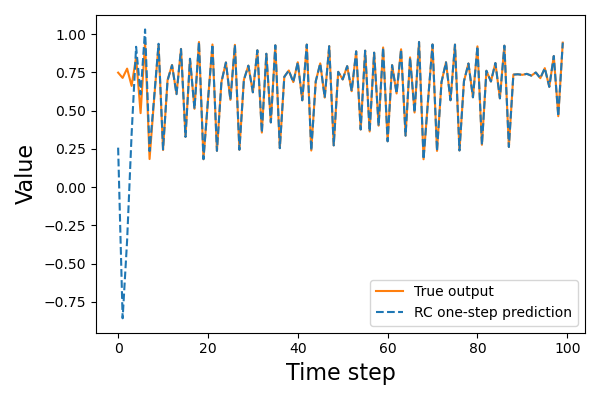

In [2]:
#simple map interpolation
# logistic map parameters
r = 3.8
T = 500

# generate sequence
s = np.zeros(T + 1)
s[0] = 0.5
for n in range(T):
    s[n+1] = r * s[n] * (1 - s[n])

# inputs and targets
U = s[:-1][:, None]      # x_n
Ytarget = s[1:][:, None]  # x_{n+1}

#train the reservoir
rc = ReservoirComputer(Nx=400, Nu=1, Ny=1, alpha=0.8, spectral_radius=0.9, density=0.05, ridge=1e-6, seed=1)
rc.train(U, Ytarget)

# test sequence - different initial condition
T_test = 100
s_test = np.zeros(T_test + 1)
s_test[0] = 0.73
for n in range(T_test):
    s_test[n+1] = r * s_test[n] * (1 - s_test[n])
U_test = s_test[:-1][:, None]
Y_true = s_test[1:][:, None]

# run reservoir on test inputs
x0 = np.zeros(rc.Nx)
X = rc.run_reservoir(U_test, x0)
bias = np.ones((len(U_test), 1))
Z = np.hstack([bias, U_test, X])
Y_pred = Z @ rc.Wout.T

#plot
plt.figure(figsize=(6, 4))
plt.plot(Y_true, label="True output", color = "tab:orange")
plt.plot(Y_pred, "--", label="RC one-step prediction", color = "tab:blue")
plt.legend()
plt.xlabel("Time step", fontsize=16)
plt.ylabel("Value", fontsize=16)
plt.tight_layout()
plt.savefig("interpolation.png", dpi=600, bbox_inches="tight")
plt.show()

## Multi-step Prediction Plot

RMSE over 20 steps = 0.1521
Prediction horizon (|error|>0.1) = 16 steps


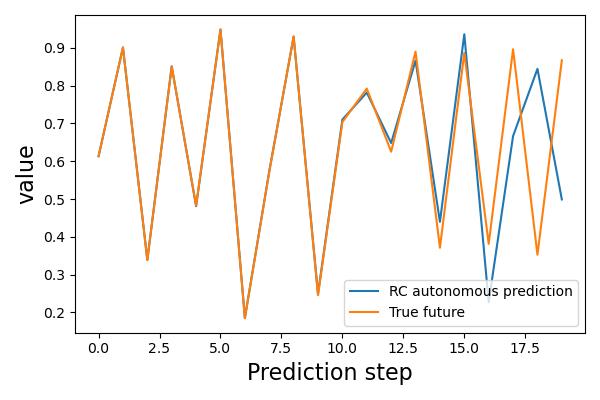

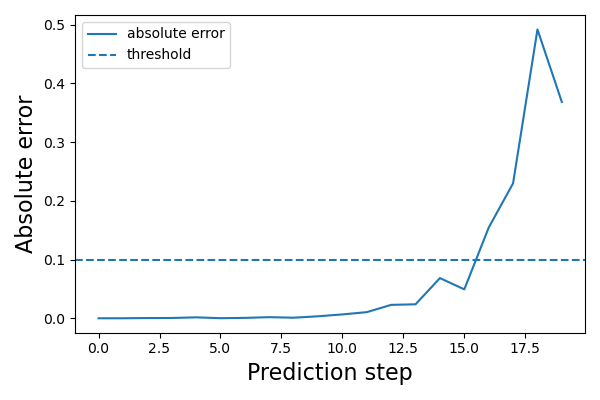

In [3]:
#predicting multiple steps in to the future after a warmup sequence - map extrapolation
#warmup sequence:
r = 3.8
T_warmup = 200
s_warm = np.zeros(T_warmup+1)
s_warm[0] = 0.2
for n in range (1,T_warmup+1):
    s_warm[n] = r*s_warm[n-1]*(1-s_warm[n-1])

#predicted sequence after warmup
U_warmup = s_warm[:-1][:,None]
K = 20
y_future = rc.predict(U_warmup, K).squeeze()

#true logistic map for these K future steps for comparison
s_future = np.zeros(K)
s0 = s_warm[-1]
for k in range(K): #continuing on sequence from up above, so starting from the last, s_test[-1]
    s0 = r * s0* (1 - s0)
    s_future[k] = s0 #looping, output from step i becomes input for step i+1
    
#error metrics
rmse = np.sqrt(np.mean((y_future.squeeze()-s_future)**2)) #y_future shape = (10,1). s_future shape = (10,). squeeze sorts this issue so rmse is accurate
err = np.abs(y_future - s_future)
threshold = 0.1  # choose what you used elsewhere
idx = np.where(err > threshold)[0]
horizon = int(idx[0]) if len(idx) > 0 else K  # steps before failure
print(f"RMSE over {K} steps = {rmse:.4g}")
print(f"Prediction horizon (|error|>{threshold}) = {horizon} steps")


#plotting
plt.figure(figsize=(6,4))
plt.plot(y_future, label="RC autonomous prediction")
plt.plot(s_future, label="True future")
plt.legend()
plt.xlabel("Prediction step", fontsize=16)
plt.ylabel("value", fontsize=16)
plt.tight_layout()
plt.savefig("extrapolation.png", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(err, label="absolute error")
plt.axhline(threshold, linestyle="--", label="threshold")
plt.legend()
plt.xlabel("Prediction step", fontsize=16)
plt.ylabel("Absolute error", fontsize=16)
plt.tight_layout()
plt.savefig("error.png", dpi=600, bbox_inches="tight")
plt.show()
